In [1]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import plotly.express as px


from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score, 
    r2_score,
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin
import math


def select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.
    
    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    - method: 'random' or 'first' or index
    
    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]
 
    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]
    
    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []
    
    for idx in df.index:
        if idx == selected_idx:
            continue
        
        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel, 
                        df.loc[idx, lat_col], 
                        df.loc[idx, lon_col])
        
        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep
    
    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()
    
    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")
    
    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    # selected, remaining, removed = select_points_stratified(sub_df, 
    #     n_per_biome=n_points_to_select,
    #     buffer_km=buffer_km,
    #     lat_col='lat',
    #     lon_col='lon',
    #     random_seed=random_key
    # )
    selected, remaining, removed = select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=random_key)
    

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])

    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c



/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': '#F4A460',      # Sandy Brown
    'Temperate conifer forests': '#FF6B6B',        # Light Red
    'Temperate grasslands': '#FFD93D',             # Light Yellow
    'Xeric shrublands': '#FF8A80',                 # Light Coral
    'Boreal and Tundra forests': '#CE93D8',        # Light Purple
    'Mediterranean woodlands': '#FFB74D',          # Light Orange
    'Tropical': '#F48FB1',                         # Light Pink
    'Flooded grasslands': '#FFA726',               # Light Orange
    'Mangroves': '#FFD54F',                        # Light Gold
    'NaN': '#CFD8DC'                               # Light Gray
}


with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

In [52]:
fd_df.columns

Index(['PID', 'Raos_Q', 'Functional_Evenness', 'Species Richness',
       'Shannon Diversity', 'Simpson's Index', 'WSCI', 'Annual Temp',
       'Annual Precipitation', 'Precipitation Seasonality', 'Soil Moisture',
       'SOC Content', 'Burnt Areas Probability', 'Elevation', 'Slope',
       'Depth to Bedrock', 'Northness', 'transformed npp', 'aridity_delta',
       'treecover2000', 'lat', 'lon', 'biome'],
      dtype='str')

## Basic Global Explainability 


In [ ]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')

fd_df.dropna(subset=['transformed npp', 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index"], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 60]

fd_df.drop_duplicates(subset=['PID'], inplace=True)

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

fd_df = fd_df[fd_df["WSCI"] != 0]
X=fd_df.drop(columns=[ 'transformed npp', 'PID', 'lat', 'lon', 'biome', 'treecover2000'])
y=fd_df['transformed npp'].values
scaler= StandardScaler()
scaler.fit_transform(X)
X = pd.DataFrame(
    X,
    columns=scaler.feature_names_in_
)

model = xgb.XGBRegressor(**config["global"])
model.fit(X, y )

y_pred = model.predict(X)



#### SHAP plots 


In [54]:
import matplotlib.pyplot as plt
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Patch
import shap

def plot_shap_with_polynomial_stats_v2(shap_values, X, div_f, div_s, degree=2, name=None):
    """Plot SHAP dependence with polynomial trend and statistics"""
    
    paired_vars = list(zip(div_f, div_s))

    colors_f = "#2E8B57"
    colors_f1="#66C2A5"
    colors_s = "#1F77B4"
    colors_s1= "#4C72B0"


    # Get data
    n_plots = len(div_f)
    n_cols = 2  # or any number you prefer
    n_rows = math.ceil(n_plots / n_cols)

    if shap_values.shape[0] < 500:
        n_samples = shap_values.shape[0]
    else:
        n_samples = 500

    # 2 rows x 2 cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2

    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        if f_var == s_var:
             # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            if np.all(feature_values == 0):
                # Skip this axis - do nothing
                pass
            else:
                # Fit polynomial
                coeffs = np.polyfit(feature_values, shap_feature, degree)
                poly_func = np.poly1d(coeffs)
            
                # Calculate R²
                y_pred = poly_func(feature_values)
                ss_res = np.sum((shap_feature - y_pred) ** 2)
                ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                indices = np.random.choice(len(feature_values), n_samples, replace=False)
                feature_values_sample = feature_values[indices]
                shap_feature_sample = shap_feature[indices]

                max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
                ax.set_ylim(-max_abs, max_abs)

                # # Scatter plot
                ax.scatter(feature_values_sample, shap_feature_sample, 
                                    alpha=0.5, s=20, c='lavender', linewidth=0.3)
                
            
                # Trend line
                x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
                y_smooth = poly_func(x_smooth)
                ax.plot(x_smooth, y_smooth, c='slategray',  linewidth=2, 
                        label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
                ax.set_xlabel(s_var)
                ax.xaxis.set_label_position('top')  # Move label to top
                ax.tick_params(axis="x")
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

        else:
            # ── Bottom x-axis: species diversity ──
            feature_idx = list(X.columns).index(s_var)
            shap_feature = shap_values[:, feature_idx].astype(np.float64)
            feature_values = X[s_var].values.astype(np.float64)

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]

            # # Scatter plot
            ax.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_s1, linewidth=0.3, zorder=1)
            

        
            # Trend line
            x_smooth1 = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth1 = poly_func(x_smooth1)
            ax.set_xlabel(s_var)
            ax.tick_params(axis="x")

            ax.plot(x_smooth1, y_smooth1, c=colors_s,  linewidth=2, 
                label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)


            # ── Top x-axis: functional diversity ──

            ax_top = ax.twiny()
            feature_idx = list(X.columns).index(f_var)
            shap_feature = shap_values[:, feature_idx]
            feature_values = X[f_var].values

            # Fit polynomial
            coeffs = np.polyfit(feature_values, shap_feature, degree)
            poly_func = np.poly1d(coeffs)
        
            # Calculate R²
            y_pred = poly_func(feature_values)
            ss_res = np.sum((shap_feature - y_pred) ** 2)
            ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
            r2 = 1 - (ss_res / ss_tot)

            indices = np.random.choice(len(feature_values), n_samples, replace=False)
            feature_values_sample = feature_values[indices]
            shap_feature_sample = shap_feature[indices]


            ax_top.scatter(feature_values_sample, shap_feature_sample, 
                                alpha=0.2, s=30, c=colors_f1, linewidth=0.3, zorder=1)


            # Trend line
            x_smooth = np.linspace(feature_values.min(), feature_values.max(), 100)
            y_smooth = poly_func(x_smooth)



            ax_top.plot(x_smooth, y_smooth, c=colors_f,  linewidth=2, 
                    label=f'Polynomial (degree {degree})\nR² = {r2:.4f}', zorder=10)
            

            y_min = min(np.min(y_smooth), np.min(y_smooth1))
            y_max = max(np.max(y_smooth), np.max(y_smooth1))

            padding = 0.1 * (y_max - y_min)

            ax.set_ylim(y_min - padding, y_max + padding)

            ax_top.set_xlabel(f_var)
            ax_top.tick_params(axis="x")
            
            # max_abs = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
            # ax.set_ylim(-0.01, 0.01)

            # Reference line
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
            # Create legend handles
            legend_elements = [Patch(facecolor=colors_s, alpha=0.6, label='Species Diversity (sdiv)'),
                            Patch(facecolor=colors_f, alpha=0.6, label='Functional Diversity (fdiv)')]

            # Add legend to the figure
            fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=11)

            # Adjust layout to make room for legend
            plt.subplots_adjust(bottom=0.12)
    if name:
        plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_shap_with_polynomial_stats_v3(shap_values, X, features, biome=None, degree=2, name=None):
    """
    Plot SHAP dependence with polynomial trend and statistics.
    Single feature list, one plot per feature, no overlapping axes.
    """

    # colors = {
    #     'scatter':"#999CC2",
    #     'line':    "#3E47C6",
    # }
    # colors = {
    #     'scatter': "#F8C1F5",
    #     'line':    "#FE4CF5",
    # }
    colors = {
        'scatter': "lavender",
        'line':    "slategray",
    }
    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    n_samples = min(shap_values.shape[0], 2000)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes_flat = np.array(axes).flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for i, (ax, var) in enumerate(zip(axes_flat, features)):

        feature_values = X[var].values.astype(np.float64)
        feature_idx = list(X.columns).index(var)
        shap_feature = shap_values[:, feature_idx].astype(np.float64)

        # Skip if all zeros
        if np.all(feature_values == 0):
            ax.set_visible(False)
            continue

        # Sample
        indices = np.random.choice(len(feature_values), n_samples, replace=False)
        fv_sample = feature_values[indices]
        sv_sample = shap_feature[indices]

        # Polynomial fit on full data
        coeffs = np.polyfit(feature_values, shap_feature, degree)
        poly_func = np.poly1d(coeffs)

        # R²
        y_pred = poly_func(feature_values)
        ss_res = np.sum((shap_feature - y_pred) ** 2)
        ss_tot = np.sum((shap_feature - np.mean(shap_feature)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        # Scatter
        ax.scatter(fv_sample, sv_sample,
                   alpha=0.3, s=20, c=colors['scatter'],
                   linewidth=0.3, zorder=1)

        # Trend line
        x_smooth = np.linspace(feature_values.min(), feature_values.max(), 200)
        y_smooth = poly_func(x_smooth)
        ax.plot(x_smooth, y_smooth,
                c=colors['line'], linewidth=2,
                zorder=10)

        y_min = min(np.min(y_smooth), np.min(y_smooth))
        y_max = max(np.max(y_smooth), np.max(y_smooth))

        padding = 0.3 * (y_max - y_min)

        ax.set_ylim(y_min - padding, y_max + padding)
        # Reference line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)

        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('SHAP value', fontsize=10)
        ax.set_title(f'{var}', fontsize=11, pad=8)
        ax.legend(fontsize=8, loc='best')

    # Hide unused axes
    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    title = f'SHAP Dependence — {biome}' if biome else 'SHAP Dependence'
    fig.suptitle(title, fontsize=13, y=1.02)

    if name:
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

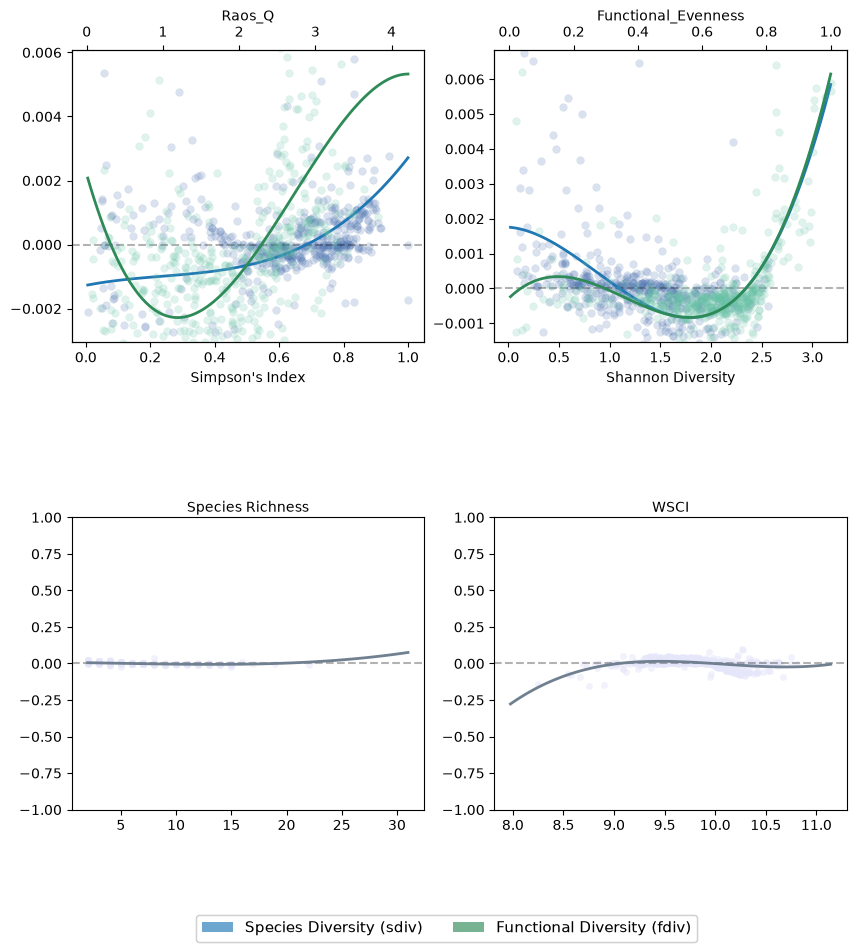

In [55]:
explainer = shap.Explainer(model, approximate=True)

shap_vals = explainer.shap_values(X, approximate=True)
mean_shap = np.abs(shap_vals).mean(axis=0)
model_features = getattr(model, "feature_names_in_", X.columns)
shap_values = explainer(X, approximate=True )

shap_importance = pd.DataFrame({
    "feature": model_features,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

diversity_vars_f = ['Raos_Q', 'Functional_Evenness', 'Species Richness', 'WSCI']
diversity_vars_s =  ["Simpson's Index", 'Shannon Diversity','Species Richness', 'WSCI']


plot_shap_with_polynomial_stats_v2(shap_vals, X, diversity_vars_f, diversity_vars_s, degree=3, name=None)

# plot_shap_with_polynomial_stats_v3(shap_vals, X, diversity_vars_f, biome=None, degree=2, name=None)

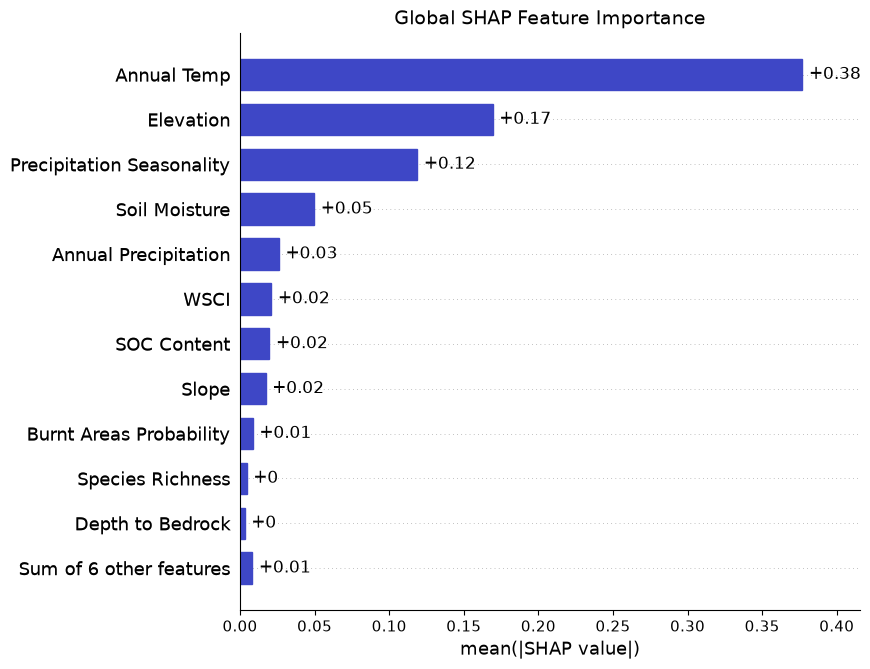

In [56]:
import shap
import matplotlib.pyplot as plt


# Create figure with desired size BEFORE shap plot
fig, ax = plt.subplots(figsize=(15, 8))  # Width=10, Height=8 inches

# Create the plot and get the Axes object
ax = shap.plots.bar(shap_values, show=False, max_display=12)

# Find all bar patches and change their color
for patch in ax.patches:
    patch.set_color("#3E47C6")

# Change text to black
for text in ax.texts:
    text.set_color('black')

# Customize title
ax.set_title("Global SHAP Feature Importance", fontsize=14)

# Display the plot
plt.show()

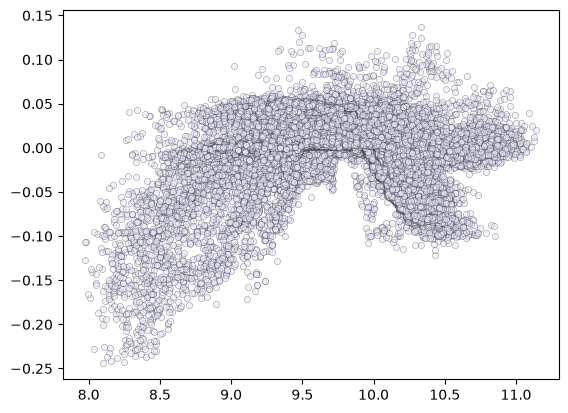

In [57]:
var="WSCI"
feature_idx = list(X.columns).index(var)

shap_feature = shap_vals[:, feature_idx].astype(np.float64)
feature_values = X[var].values.astype(np.float64)

# # Scatter plot
plt.scatter(feature_values, shap_feature    , 
                    alpha=0.5, s=20, c='lavender', edgecolors='black', linewidth=0.3)


#### UMapping


In [58]:

s_2d = UMAP(
    n_neighbors=30,
    min_dist=0.05,
    metric="cosine",   # sometimes faster + better for SHAP
    n_jobs=-1,
    low_memory=True
).fit_transform(shap_vals)

In [59]:

def plot_umap_by_features(s_2d, X, features, cmap='viridis', name=None):
    ncols = 2
    nrows = (len(features) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = axes.flatten()
    fig.subplots_adjust(hspace=0.5, wspace=0.4)

    for ax, feat in zip(axes_flat, features):
        sc = ax.scatter(
            s_2d[:, 0], s_2d[:, 1],
            c=X[feat].values,
            cmap=cmap,
            s=5,
            alpha=0.6
        )
        plt.colorbar(sc, ax=ax, label=feat)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.spines[['right', 'top']].set_visible(False)

    # Hide unused axes
    for ax in axes_flat[len(features):]:
        ax.set_visible(False)

    plt.suptitle("UMAP of SHAP values coloured by feature", fontsize=13, y=1.02)
    if name:
        plt.savefig(name, dpi=150, bbox_inches="tight")
    plt.show()

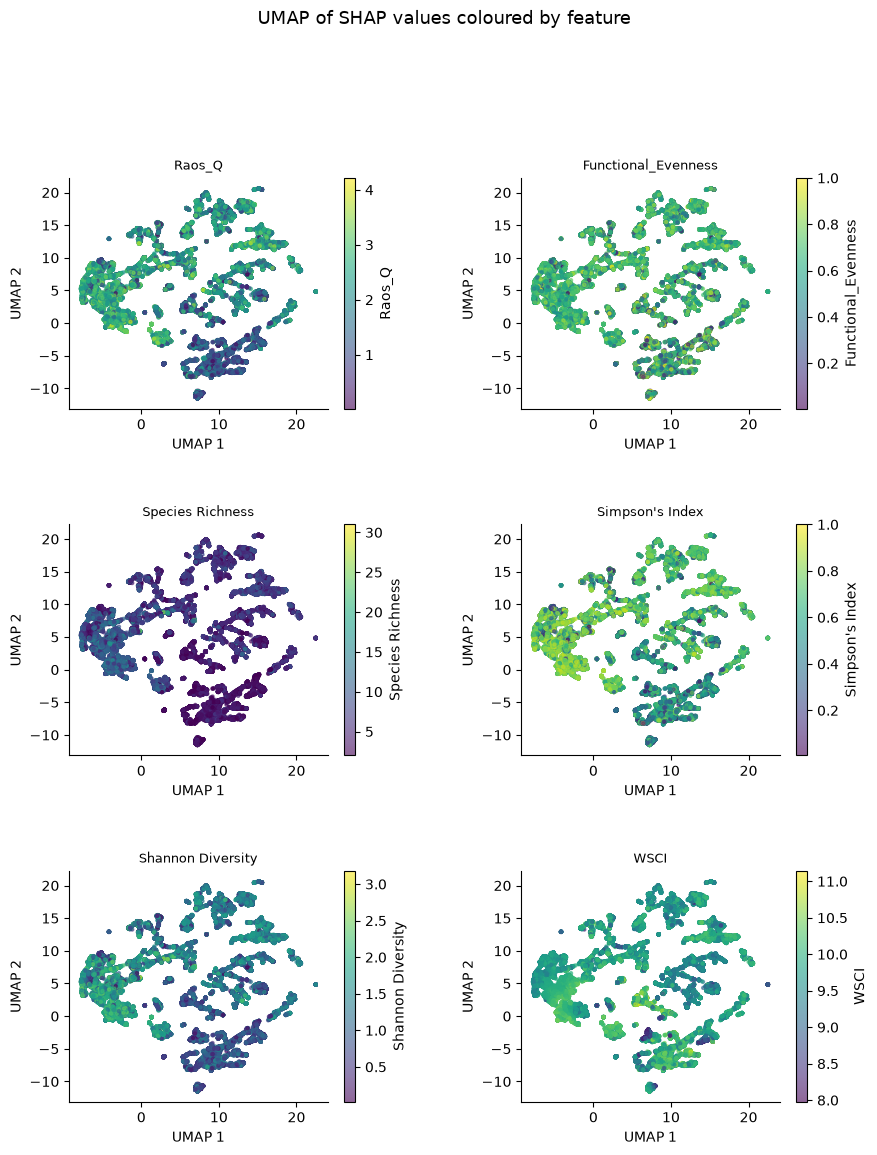

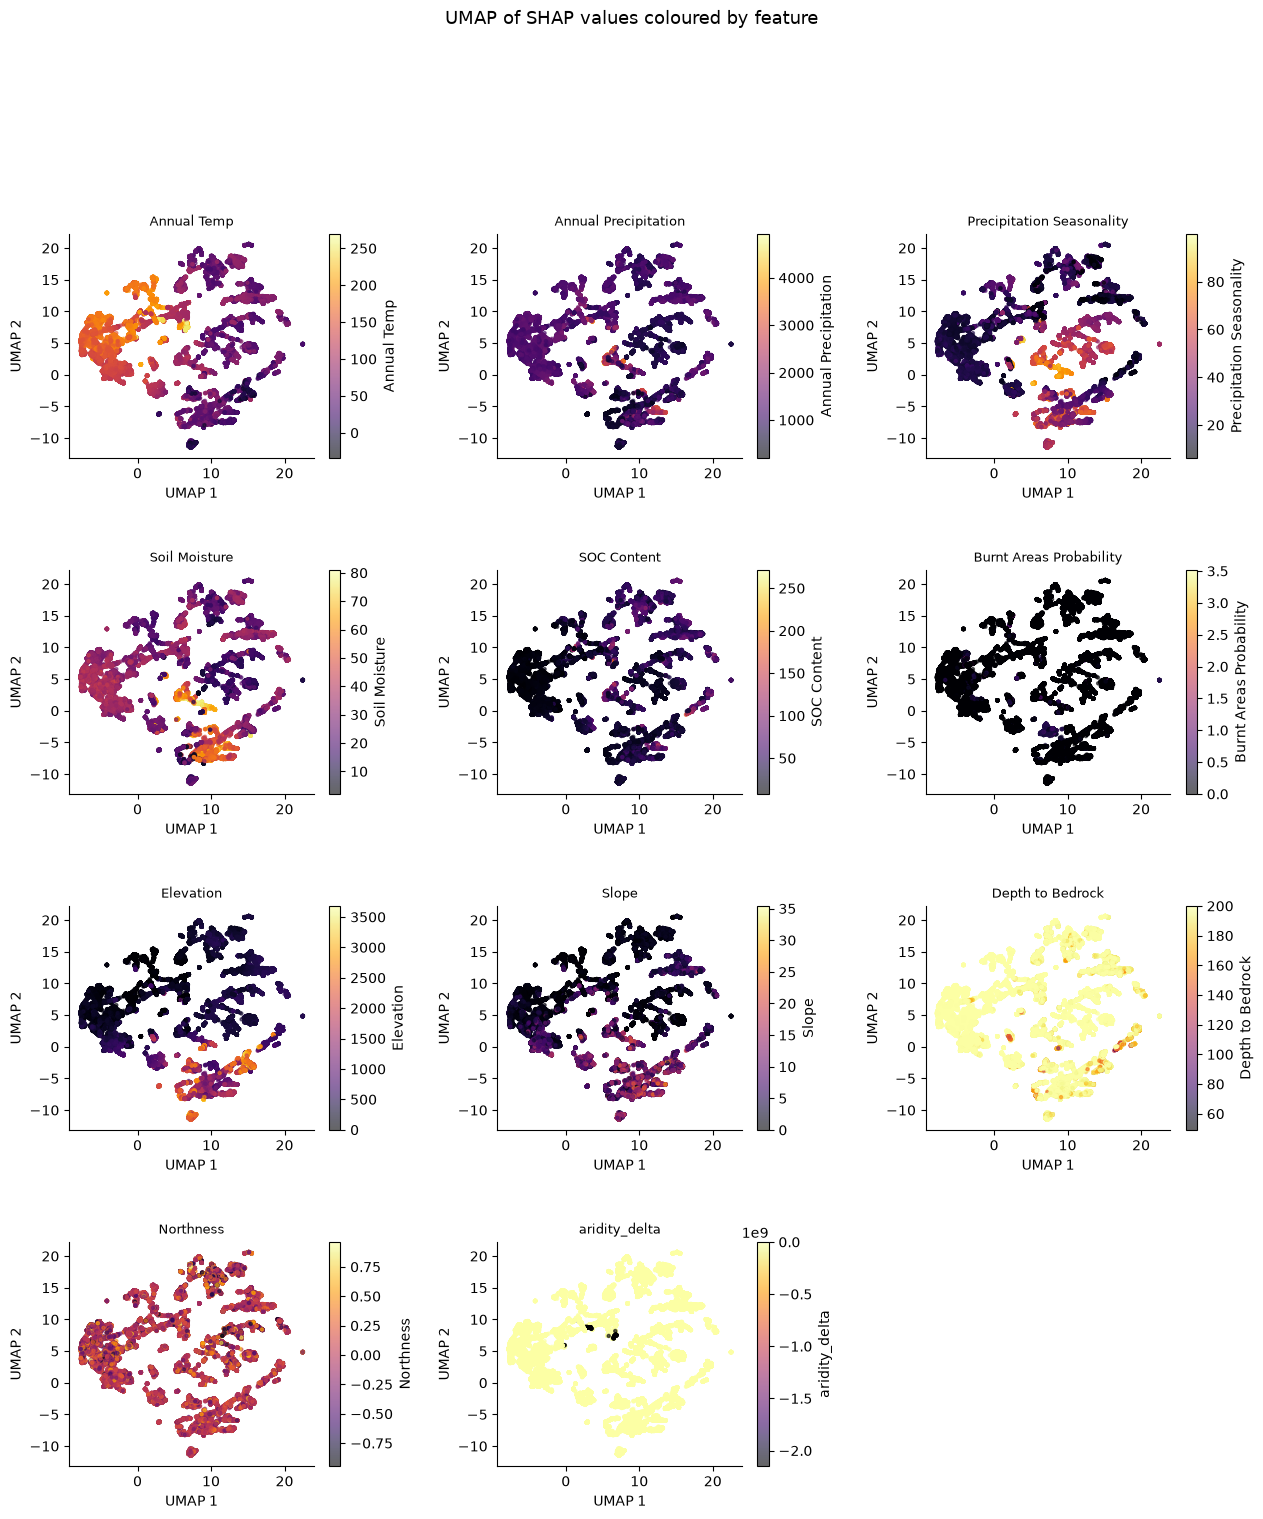

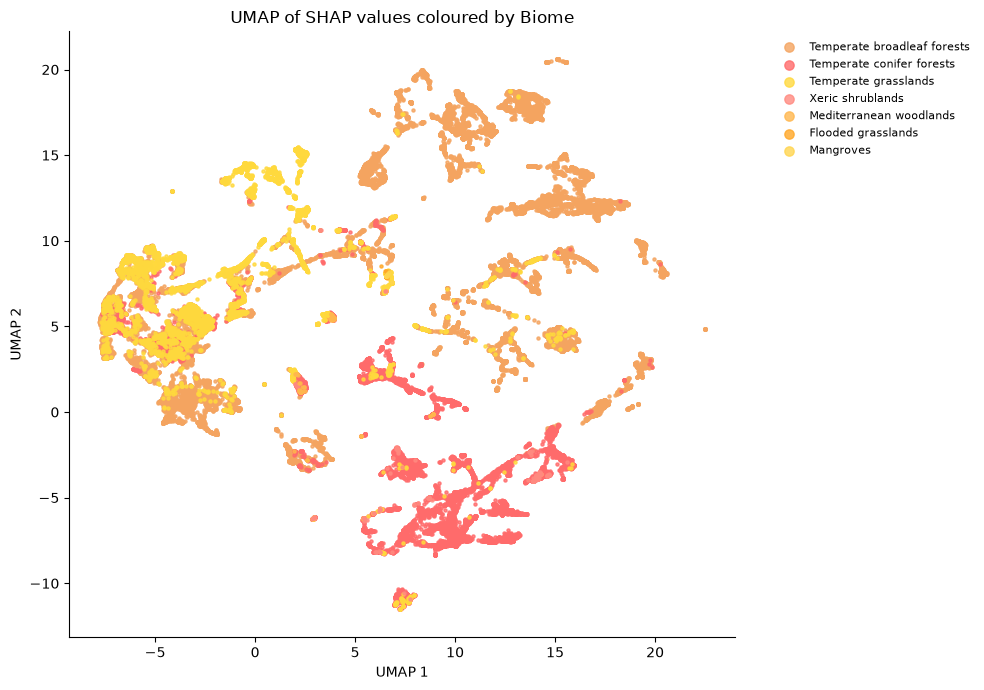

In [60]:
feature_list = ['Raos_Q','Functional_Evenness','Species Richness',
                "Simpson's Index", 'Shannon Diversity', 'WSCI']

plot_umap_by_features(s_2d, fd_df, cmap="viridis", features=feature_list,)

feature_list1 = [feat for feat in X.columns if feat not in feature_list]

uutil.plot_umap_by_features(s_2d, fd_df, cmap="inferno", features=feature_list1, name=None)
uutil.plot_umap_biome(s_2d, fd_df, biome_colors, name="figures/umap_shap_biome.png")

In [25]:
biome_labels = fd_df['biome'].values

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in feature_list :
    vals = fd_df[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")


est2 = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile',  quantile_method='averaged_inverted_cdf')

results = []

for biome in biome_list:
    mask = biome_labels == biome
    X_filtered = X[mask]
    s_2d_filtered = s_2d[mask]
    n = len(s_2d_filtered)
    
    # Skip biomes with too few samples
    if n < 50:
        print(f"Skipping {biome}: only {n} samples")
        continue
    
    for feat in feature_list:
        try:
            vals = X_filtered[feat].values.reshape(-1, 1)
            labels = est2.fit_transform(vals).astype(int).flatten()
            
            # Skip if only one class after binning
            if len(set(labels)) < 2:
                continue
                
            score = silhouette_score(s_2d_filtered, labels, random_state=42)
            results.append({'biome': biome, 'feature': feat, 'silhouette': score, 'n': n})
            
        except Exception as e:
            print(f"Failed {biome} / {feat}: {e}")

# Summarise as a readable table
results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='biome', columns='feature', values='silhouette').round(3)


Raos_Q                         Silhouette: 0.064
Simpson's Index                Silhouette: 0.049
Functional_Evenness            Silhouette: 0.004
Shannon Diversity              Silhouette: 0.063
Species Richness               Silhouette: 0.095


/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/qli/Projects/env1/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [9]:
biome_labels = fd_df['biome'].values

est = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile', quantile_method='averaged_inverted_cdf')

for feat in feature_list :
    vals = fd_df[feat].values.reshape(-1, 1)
    labels = est.fit_transform(vals).astype(int).flatten()
    score = silhouette_score(s_2d, labels, sample_size=10000, random_state=42)
    print(f"{feat:30s} Silhouette: {score:.3f}")


Raos_Q                         Silhouette: 0.067
Simpson's Index                Silhouette: 0.053
Functional_Evenness            Silhouette: 0.004
Shannon Diversity              Silhouette: 0.068
Species Richness               Silhouette: 0.101
WSCI                           Silhouette: 0.042


In [10]:
pivot

feature,Functional_Evenness,Raos_Q,Shannon Diversity,Simpson's Index,Species Richness,WSCI
biome,,,,,,
Boreal and Tundra forests,0.011,0.013,0.011,0.004,NaN,NaN
Mediterranean woodlands,-0.001,0.005,0.012,0.004,0.040,0.032
Temperate broadleaf forests,0.006,0.038,0.075,0.059,0.094,0.050
Temperate conifer forests,0.004,0.034,0.008,0.005,-0.036,0.078
Temperate grasslands,0.003,0.022,0.030,0.016,0.080,0.134
Tropical,0.000,0.041,0.045,0.020,0.011,0.261
Xeric shrublands,0.000,0.003,0.000,0.004,NaN,0.053


#### Shap on a Map! 


In [18]:

# Define your feature list
feature_list = ['Raos_Q', 'Functional_Evenness', "Simpson's Index", 'Shannon Diversity', ]  

# Define colors
color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}

In [19]:
def get_dominant_feature(row):
    """Return the feature name with the largest absolute SHAP value"""

    abs_shaps = {col: abs(row[col]) for col in shap_cols} #Lack of shap_cols Maaaaay cause a bug
    dominant = max(abs_shaps, key=abs_shaps.get)
    
    return dominant.replace('shap_', '')

all_shap_df = pd.DataFrame(
        shap_vals,
        columns=[f'shap_{col}' for col in X.columns],
        index=X.index
    )

shap_df = all_shap_df[[f'shap_{col}' for col in feature_list]]

# Merge with PID, lat, lon
results = pd.concat([
    fd_df[['PID', 'lat', 'lon']],
    shap_df
], axis=1)

shap_cols = [col for col in results.columns if col.startswith('shap_')]

results['dominant_feature'] = results.apply(get_dominant_feature, axis=1)


# Create the map
fig = px.scatter_map(
    results,
    lat='lat',
    lon='lon',
    color='dominant_feature',
    color_discrete_map=color_map,
    hover_data=['PID', 'dominant_feature'],
    title='Spatial Distribution of Dominant SHAP Features',
    zoom=6,
    center={'lat': results['lat'].mean(), 'lon': results['lon'].mean()},
    size=[5]*len(results),  # Consistent point size
    opacity=1
)


fig.update_traces(marker=dict(size=5, opacity=0.85))
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": "traces",
            "sourcetype": "raster",
            "sourceattribution": "Natural Earth",
            "source": [
                "https://basemaps.cartocdn.com/light_nolabels/{z}/{x}/{y}.png"
            ]
        }
    ],
    width=1500, 
    height=900,
    legend=dict(
        title=dict(text="Species vs Functional Div", font=dict(size=16)),
        font=dict(size=14),
        itemsizing='constant'
    )
)

# Save to HTML
fig.write_html("figures/shap_map.html")
